# 01 — Charts (Top 200 e Viral 50)

**O que vamos olhar e por quê.** Os charts são o sinal que o modelo precisa prever. Antes de qualquer coisa, é importante saber: quão completos são, quantas músicas distintas aparecem, e que formatos de trajetória de popularidade existem. Essas trajetórias são o que SIR/wave-based tentam capturar; entender a forma delas ajuda a justificar (e a criticar) o uso de um GNN.

Fontes:
- **MGD+** Top 200 BR — `data/MGDplus/charts/regional/spotify_charts_regional_br.csv` (completo, 2017-01 → 2022-03).
- **Kaggle** — `data/charts/spotify_charts_br_2017_2021.csv` (única fonte pública do Viral 50, ~60% por dia).

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "exploration":
    ROOT = ROOT.parent
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT / "src"))
from music_diffusion_gnn.data.loaders import load_charts

# Loader auto-detecta MGD+ se data/charts/mgdplus/ existir.
# Para usar o Top 200 do MGD+, basta:
#   mkdir -p data/charts/mgdplus
#   cp data/MGDplus/charts/regional/spotify_charts_regional_br.csv data/charts/mgdplus/
charts = load_charts()
print("linhas:", f"{len(charts):,}")
print("período:", charts['date'].min().date(), "→", charts['date'].max().date())
print("charts:", sorted(charts['chart'].dropna().unique()))
charts.head()

linhas: 280,932
período: 2017-01-01 → 2021-12-31
charts: ['top200', 'viral50']


,song_id,date,rank,chart,streams
0,494OU6M7NOf4ICYb4zWCf5,2017-01-02,126,top200,37128.0
1,0EPxmvsG1BY5td4aTOkWBF,2017-01-01,1,top200,612271.0
2,2wFnRPjuqwNySFiK0Qfg8L,2017-01-01,3,top200,228307.0
3,45wqPwIH4A5cr2IyyD4WKf,2017-01-01,4,top200,217394.0
4,2CW04trIoYMbroZWDzPAjs,2017-01-01,6,top200,209183.0


## 1) Cobertura diária

Quantas músicas aparecem em cada chart, por dia? Top 200 deveria ter exatamente 200 IDs únicos/dia (raramente menos, por empates). Viral 50 deveria ter 50/dia — mas o scraper do Kaggle perdeu pedaços.

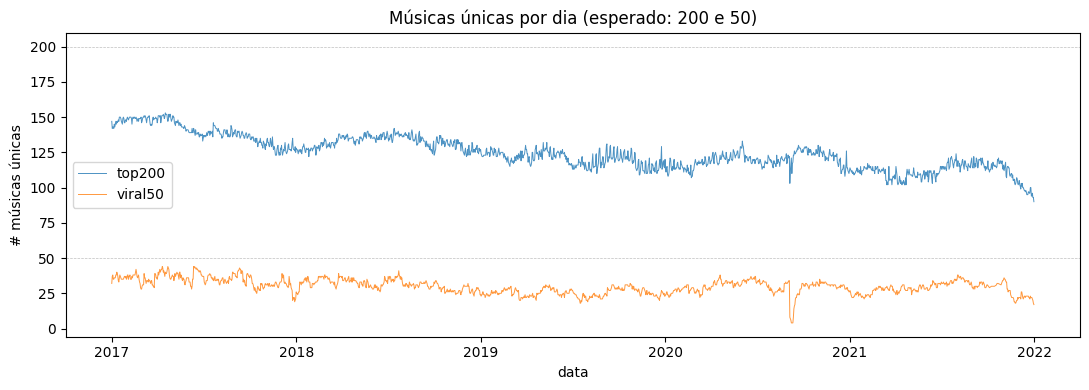


Resumo de completude por chart:
         dias  media_por_dia  mediana  min_por_dia  max_por_dia
chart                                                          
top200   1823          124.6    123.0           90          153
viral50  1800           29.9     30.0            4           44


In [2]:
daily = (
    charts.groupby(['date', 'chart'])['song_id']
    .nunique()
    .rename('n_unique_songs')
    .reset_index()
)
fig, ax = plt.subplots(figsize=(11, 4))
for chart_name, sub in daily.groupby('chart'):
    ax.plot(sub['date'], sub['n_unique_songs'], label=chart_name, lw=0.7, alpha=0.8)
ax.axhline(200, color='gray', ls='--', lw=0.5, alpha=0.5)
ax.axhline(50,  color='gray', ls='--', lw=0.5, alpha=0.5)
ax.set_title('Músicas únicas por dia (esperado: 200 e 50)')
ax.set_xlabel('data')
ax.set_ylabel('# músicas únicas')
ax.legend()
plt.tight_layout(); plt.show()

print('\nResumo de completude por chart:')
summary = daily.groupby('chart').agg(
    dias=('date', 'nunique'),
    media_por_dia=('n_unique_songs', 'mean'),
    mediana=('n_unique_songs', 'median'),
    min_por_dia=('n_unique_songs', 'min'),
    max_por_dia=('n_unique_songs', 'max'),
).round(1)
print(summary)

**Leitura:** se aparecer ~200 músicas/dia para `top200`, o Top 200 está completo. Para `viral50`, o esperado é uma média bem abaixo de 50 (memória de projeto registrou ~30/dia). Esse gap é a maior limitação do nosso subset (1.179 vs 1.977 do paper).

## 2) Quanto tempo cada música fica no chart?

Distribuição do número de aparições por música (`song_id`), separada por chart. Cauda longa esperada: maioria entra e some, poucas grudam.

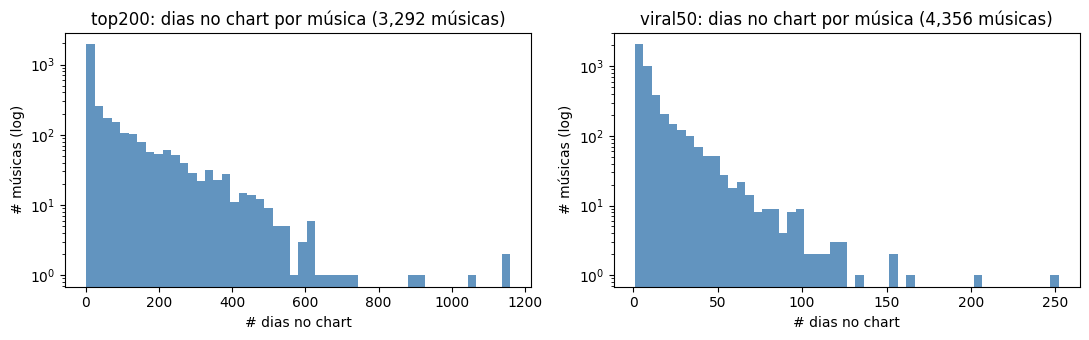


Quantis de "dias no chart":
          count  mean    std  min   50%   75%    90%    99%     max
chart                                                              
top200   3292.0  69.0  117.6  1.0  12.0  85.2  226.0  501.0  1160.0
viral50  4356.0  12.3   16.8  1.0   7.0  14.0   31.0   85.0   252.0


In [3]:
appear = (
    charts.groupby(['chart', 'song_id'])['date']
    .nunique()
    .rename('dias_no_chart')
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (chart_name, sub) in zip(axes, appear.groupby('chart')):
    ax.hist(sub['dias_no_chart'], bins=50, color='steelblue', alpha=0.85)
    ax.set_yscale('log')
    ax.set_title(f'{chart_name}: dias no chart por música ({sub.shape[0]:,} músicas)')
    ax.set_xlabel('# dias no chart')
    ax.set_ylabel('# músicas (log)')
plt.tight_layout(); plt.show()

print('\nQuantis de "dias no chart":')
print(appear.groupby('chart')['dias_no_chart'].describe(percentiles=[0.5, 0.75, 0.9, 0.99]).round(1))

**Leitura:** os percentis altos (P99) mostram quem são os "hits longos" — exatamente onde o SIR clássico erra mais (no paper, RMSE ~2× maior que viralidade curta). É justamente onde esperamos que o GNN com sinal relacional ajude.

## 3) Trajetórias de popularidade

Pegamos algumas músicas com perfis bem diferentes e plotamos a curva normalizada (idêntica à do paper: rank → rank_score → MA-7d → escalado em [0, 0.5]). É essa curva que SIR e wave-based tentam ajustar.

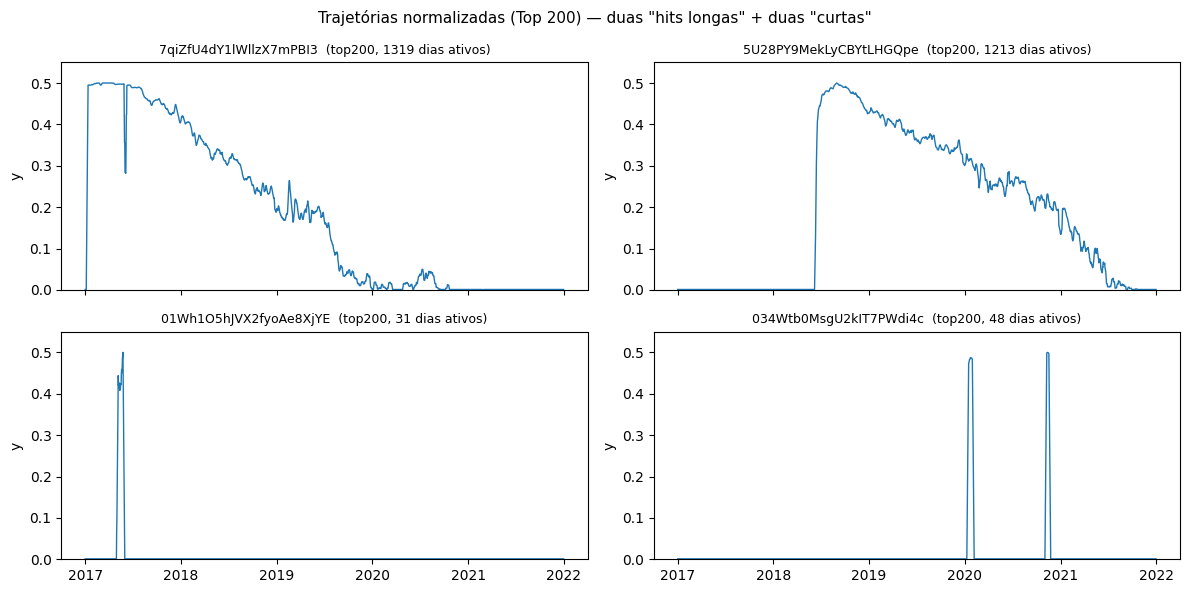

In [4]:
# Pré-processamento idêntico ao paper, inline (evita reconstruir o parquet completo).
_MAX_RANK = {'top200': 200, 'viral50': 50}

def trajectory(song_id, chart_name='top200', window=7, target_max=0.5, floor=0.001):
    sub = charts[(charts['song_id'] == song_id) & (charts['chart'] == chart_name)].copy()
    if sub.empty:
        return None
    max_rank = _MAX_RANK[chart_name]
    sub['rank_score'] = max_rank - sub['rank'] + 1
    full_idx = pd.date_range(charts['date'].min(), charts['date'].max(), freq='D')
    s = sub.set_index('date')['rank_score'].reindex(full_idx).fillna(0)
    smoothed = s.rolling(window=window, min_periods=1).mean()
    rng = smoothed.max() - smoothed.min()
    norm = (smoothed - smoothed.min()) / rng * target_max if rng > 0 else smoothed * 0.0
    return norm.where(norm > 0, floor)

# Heurística: pegar 2 hits longos + 2 viralidades curtas + 2 com pico atrasado/re-emergência
long_hits = appear[appear['chart'] == 'top200'].nlargest(50, 'dias_no_chart')['song_id'].head(2).tolist()
short_pop = appear[(appear['chart'] == 'top200') & (appear['dias_no_chart'].between(20, 50))]['song_id'].head(2).tolist()

samples = long_hits + short_pop
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for ax, sid in zip(axes.flat, samples):
    y = trajectory(sid, 'top200')
    if y is None:
        continue
    ax.plot(y.index, y.values, color='C0', lw=1.0)
    ax.set_title(f'{sid}  (top200, {(y > 0.001).sum()} dias ativos)', fontsize=9)
    ax.set_ylim(0, 0.55)
    ax.set_ylabel('y')
fig.suptitle('Trajetórias normalizadas (Top 200) — duas "hits longas" + duas "curtas"', fontsize=11)
plt.tight_layout(); plt.show()

**Leitura:** o formato "sino" das trajetórias curtas é o que o SIR clássico ajusta bem. Os perfis longos (com platôs ou múltiplos picos) é onde a história fica complicada — multi-wave (ASONAM 2025) tenta cobrir, mas pacotes inteiros de comportamento ficam de fora se você só olha a série temporal isolada da música.

## Insight para o GNN

1. **Granularidade temporal:** **dia**. É a frequência natural dos dados, e bate com o pré-processamento do paper. Os snapshots do grafo dinâmico (Phase 1) devem ser diários ou agregar pequenas janelas de dias.
2. **Período útil:** ~2017-01 → 2021-12 com Kaggle; 2017-01 → 2022-03 só com MGD+ Top 200. O Viral 50 limita o subset experimental ao período do Kaggle.
3. **Target por música:** trajetória normalizada `y` (mesma do paper). Para o GNN, isso vira **feature dinâmica do nó `music`** (ou o output de uma cabeça de regressão temporal).
4. **Onde o sinal estrutural deve aparecer:** nas "hits longas" (P95+ em dias no chart). É a faixa onde modelos populacionais erram mais — e onde colaborações/gênero deveriam puxar previsões em direção a artistas/gêneros similares.
5. **Limitação a declarar:** Viral 50 ~60% completo no público; nosso subset será menor que o do paper. Documentar.